# Import Model

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset 
data = pd.read_csv("Prostate_Cancer.csv")



# Looking at The Data

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 100 non-null    int64  
 1   diagnosis_result   100 non-null    object 
 2   radius             100 non-null    int64  
 3   texture            100 non-null    int64  
 4   perimeter          100 non-null    int64  
 5   area               100 non-null    int64  
 6   smoothness         100 non-null    float64
 7   compactness        100 non-null    float64
 8   symmetry           100 non-null    float64
 9   fractal_dimension  100 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 7.9+ KB
None


In [5]:
print(data.describe())

               id      radius     texture   perimeter         area  \
count  100.000000  100.000000  100.000000  100.000000   100.000000   
mean    50.500000   16.850000   18.230000   96.780000   702.880000   
std     29.011492    4.879094    5.192954   23.676089   319.710895   
min      1.000000    9.000000   11.000000   52.000000   202.000000   
25%     25.750000   12.000000   14.000000   82.500000   476.750000   
50%     50.500000   17.000000   17.500000   94.000000   644.000000   
75%     75.250000   21.000000   22.250000  114.250000   917.000000   
max    100.000000   25.000000   27.000000  172.000000  1878.000000   

       smoothness  compactness    symmetry  fractal_dimension  
count  100.000000   100.000000  100.000000         100.000000  
mean     0.102730     0.126700    0.193170           0.064690  
std      0.014642     0.061144    0.030785           0.008151  
min      0.070000     0.038000    0.135000           0.053000  
25%      0.093500     0.080500    0.172000       

In [6]:
# Class distribution
print(data['diagnosis_result'].value_counts())

M    62
B    38
Name: diagnosis_result, dtype: int64


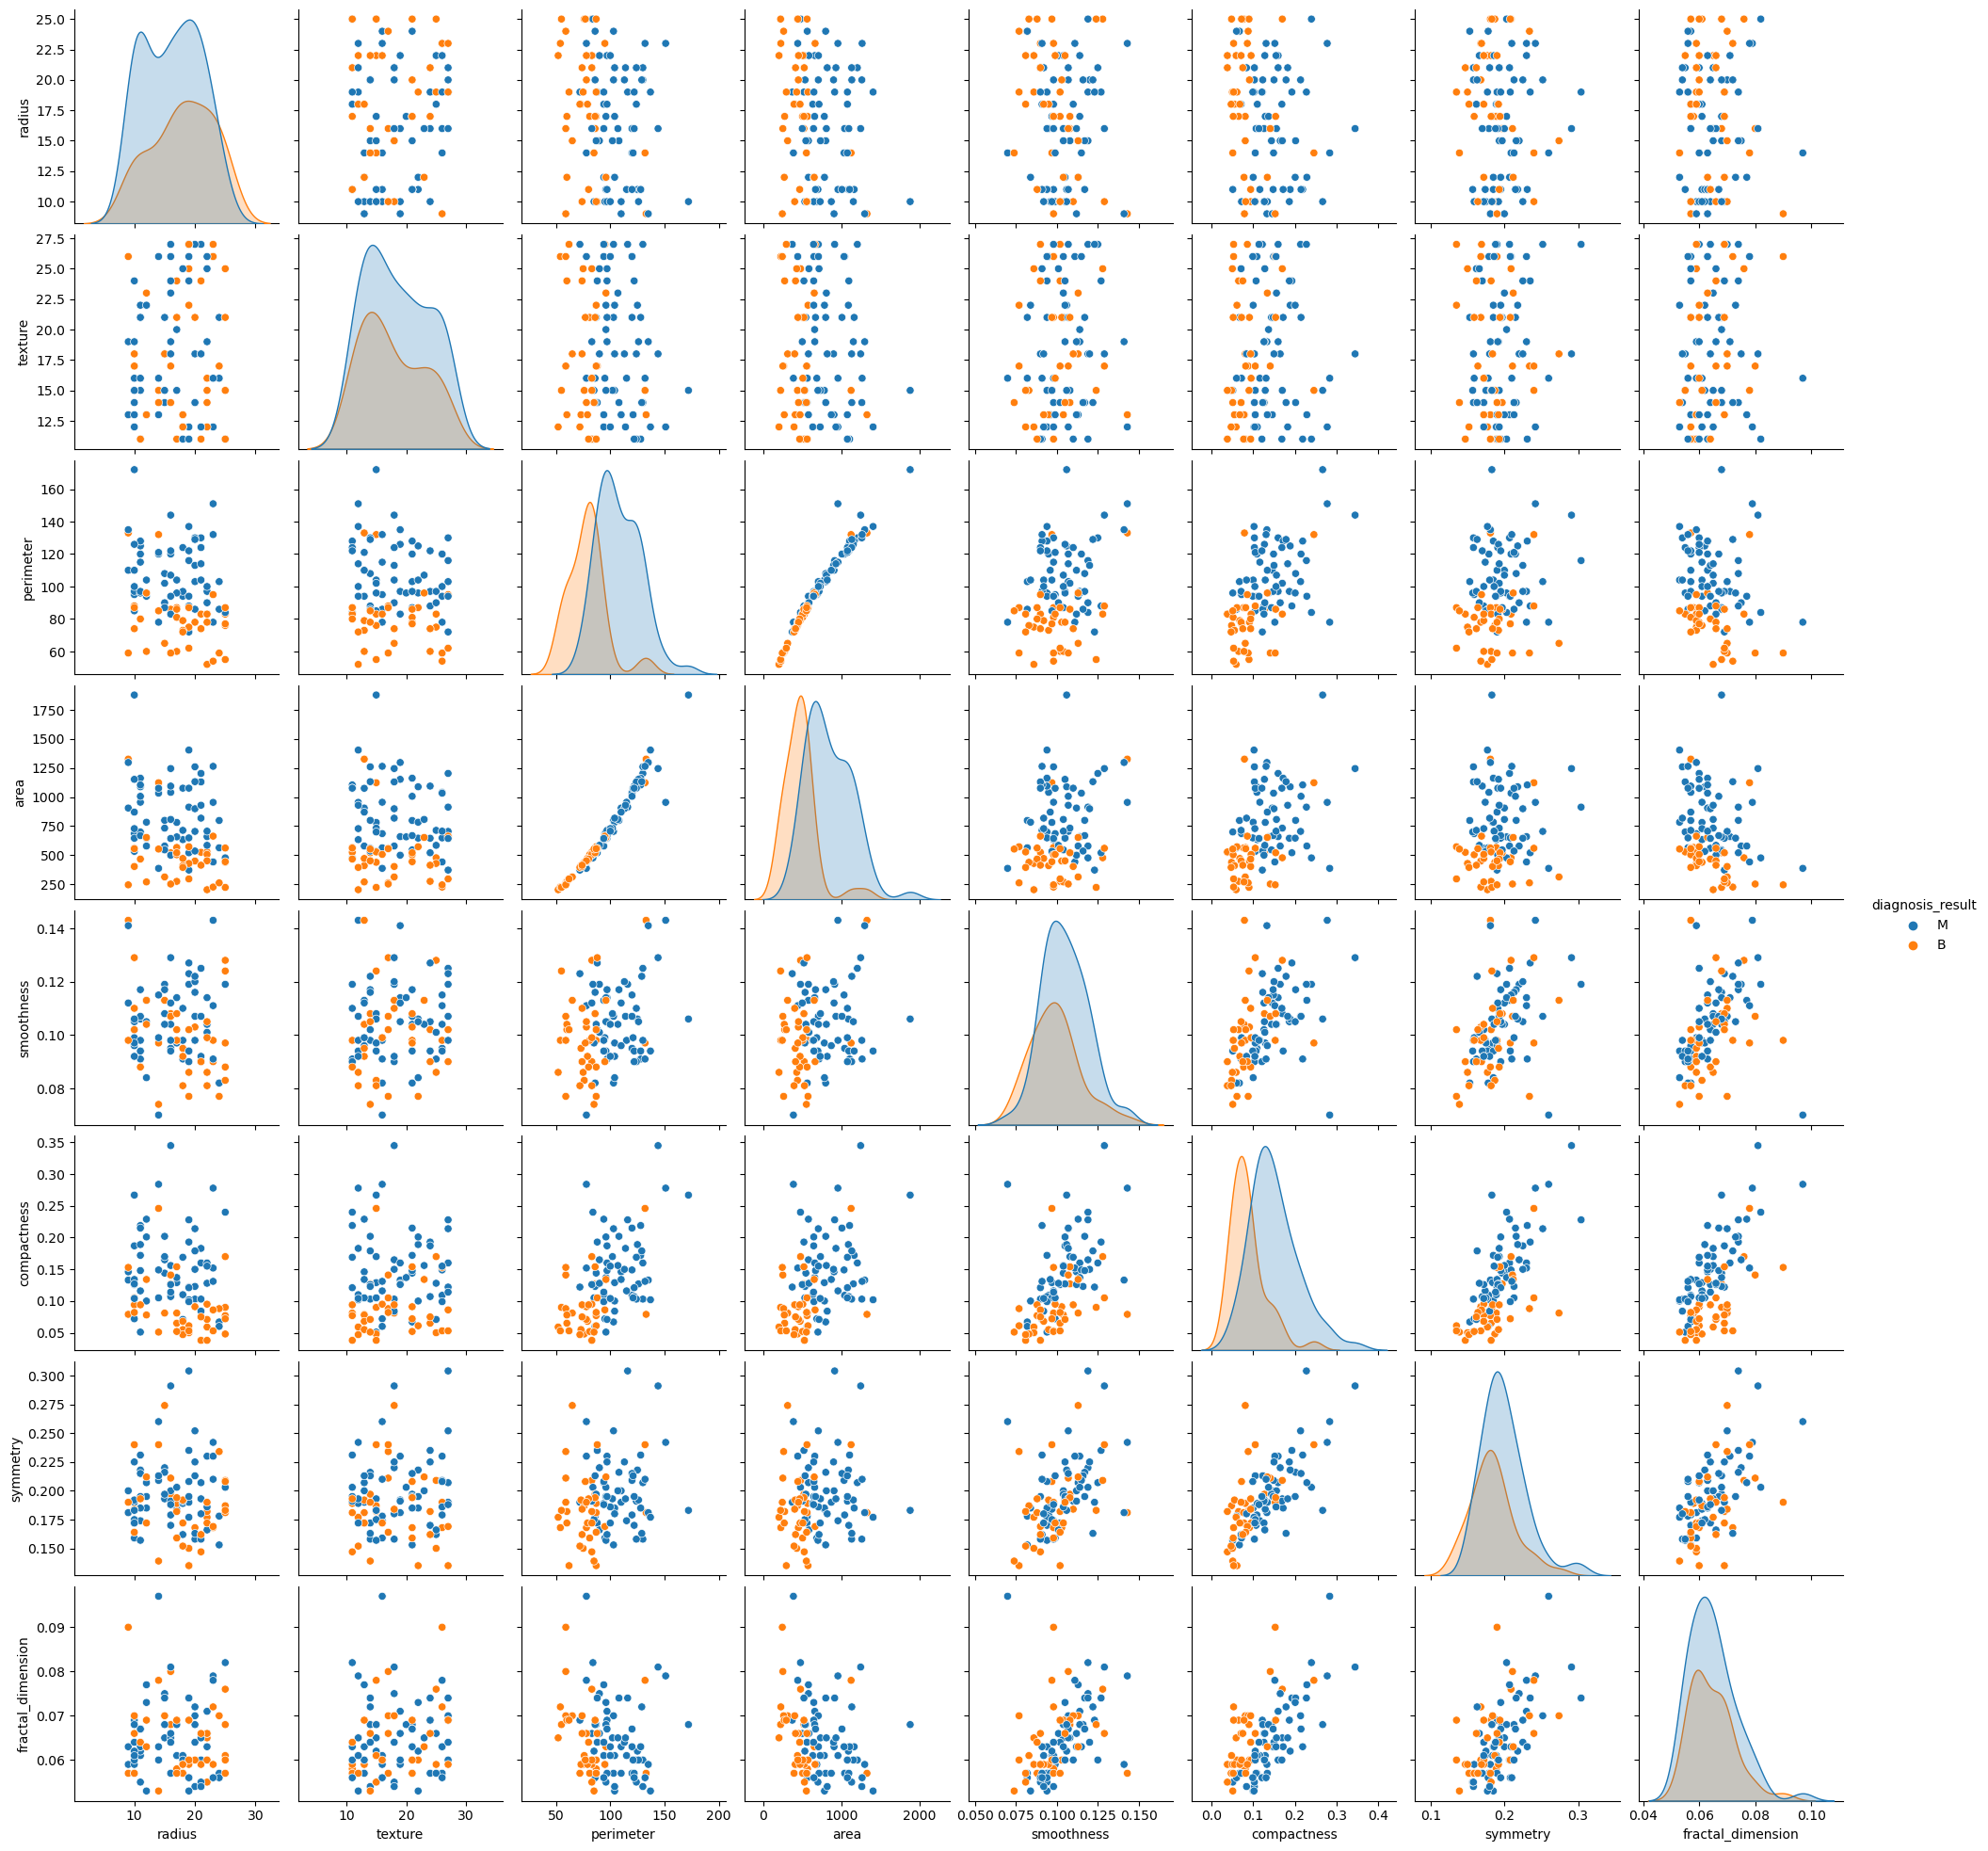

In [7]:
# Data distribution and correlations
sns.pairplot(data.drop(['id'], axis=1), hue='diagnosis_result')
plt.show()

C:\Users\Jlee\AppData\Local\Temp\ipykernel_19988\2960152716.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = data.corr()


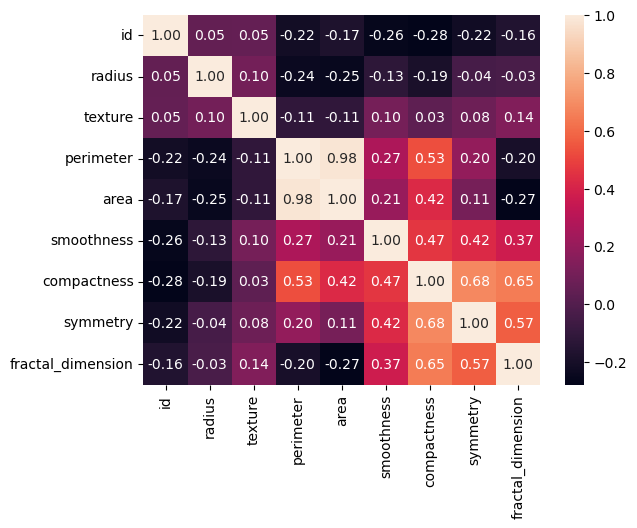

In [8]:
# Correlation matrix
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.show()

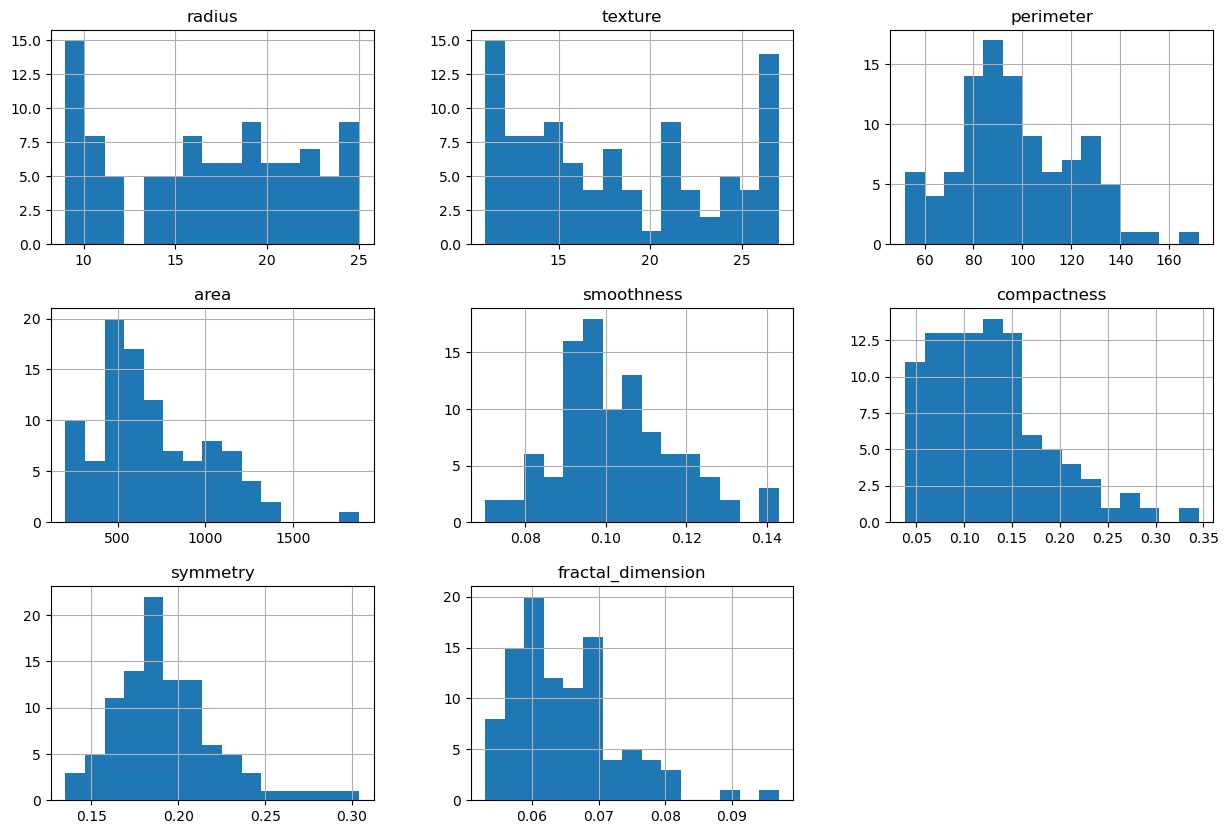

In [9]:
# Feature distributions
data.drop(['id', 'diagnosis_result'], axis=1).hist(bins=15, figsize=(15, 10))
plt.show()

In [10]:
# Check for missing values
print(data.isnull().sum())

id                   0
diagnosis_result     0
radius               0
texture              0
perimeter            0
area                 0
smoothness           0
compactness          0
symmetry             0
fractal_dimension    0
dtype: int64


# Target Variable and Scale  Features

Exploratory Data Analysis (EDA)

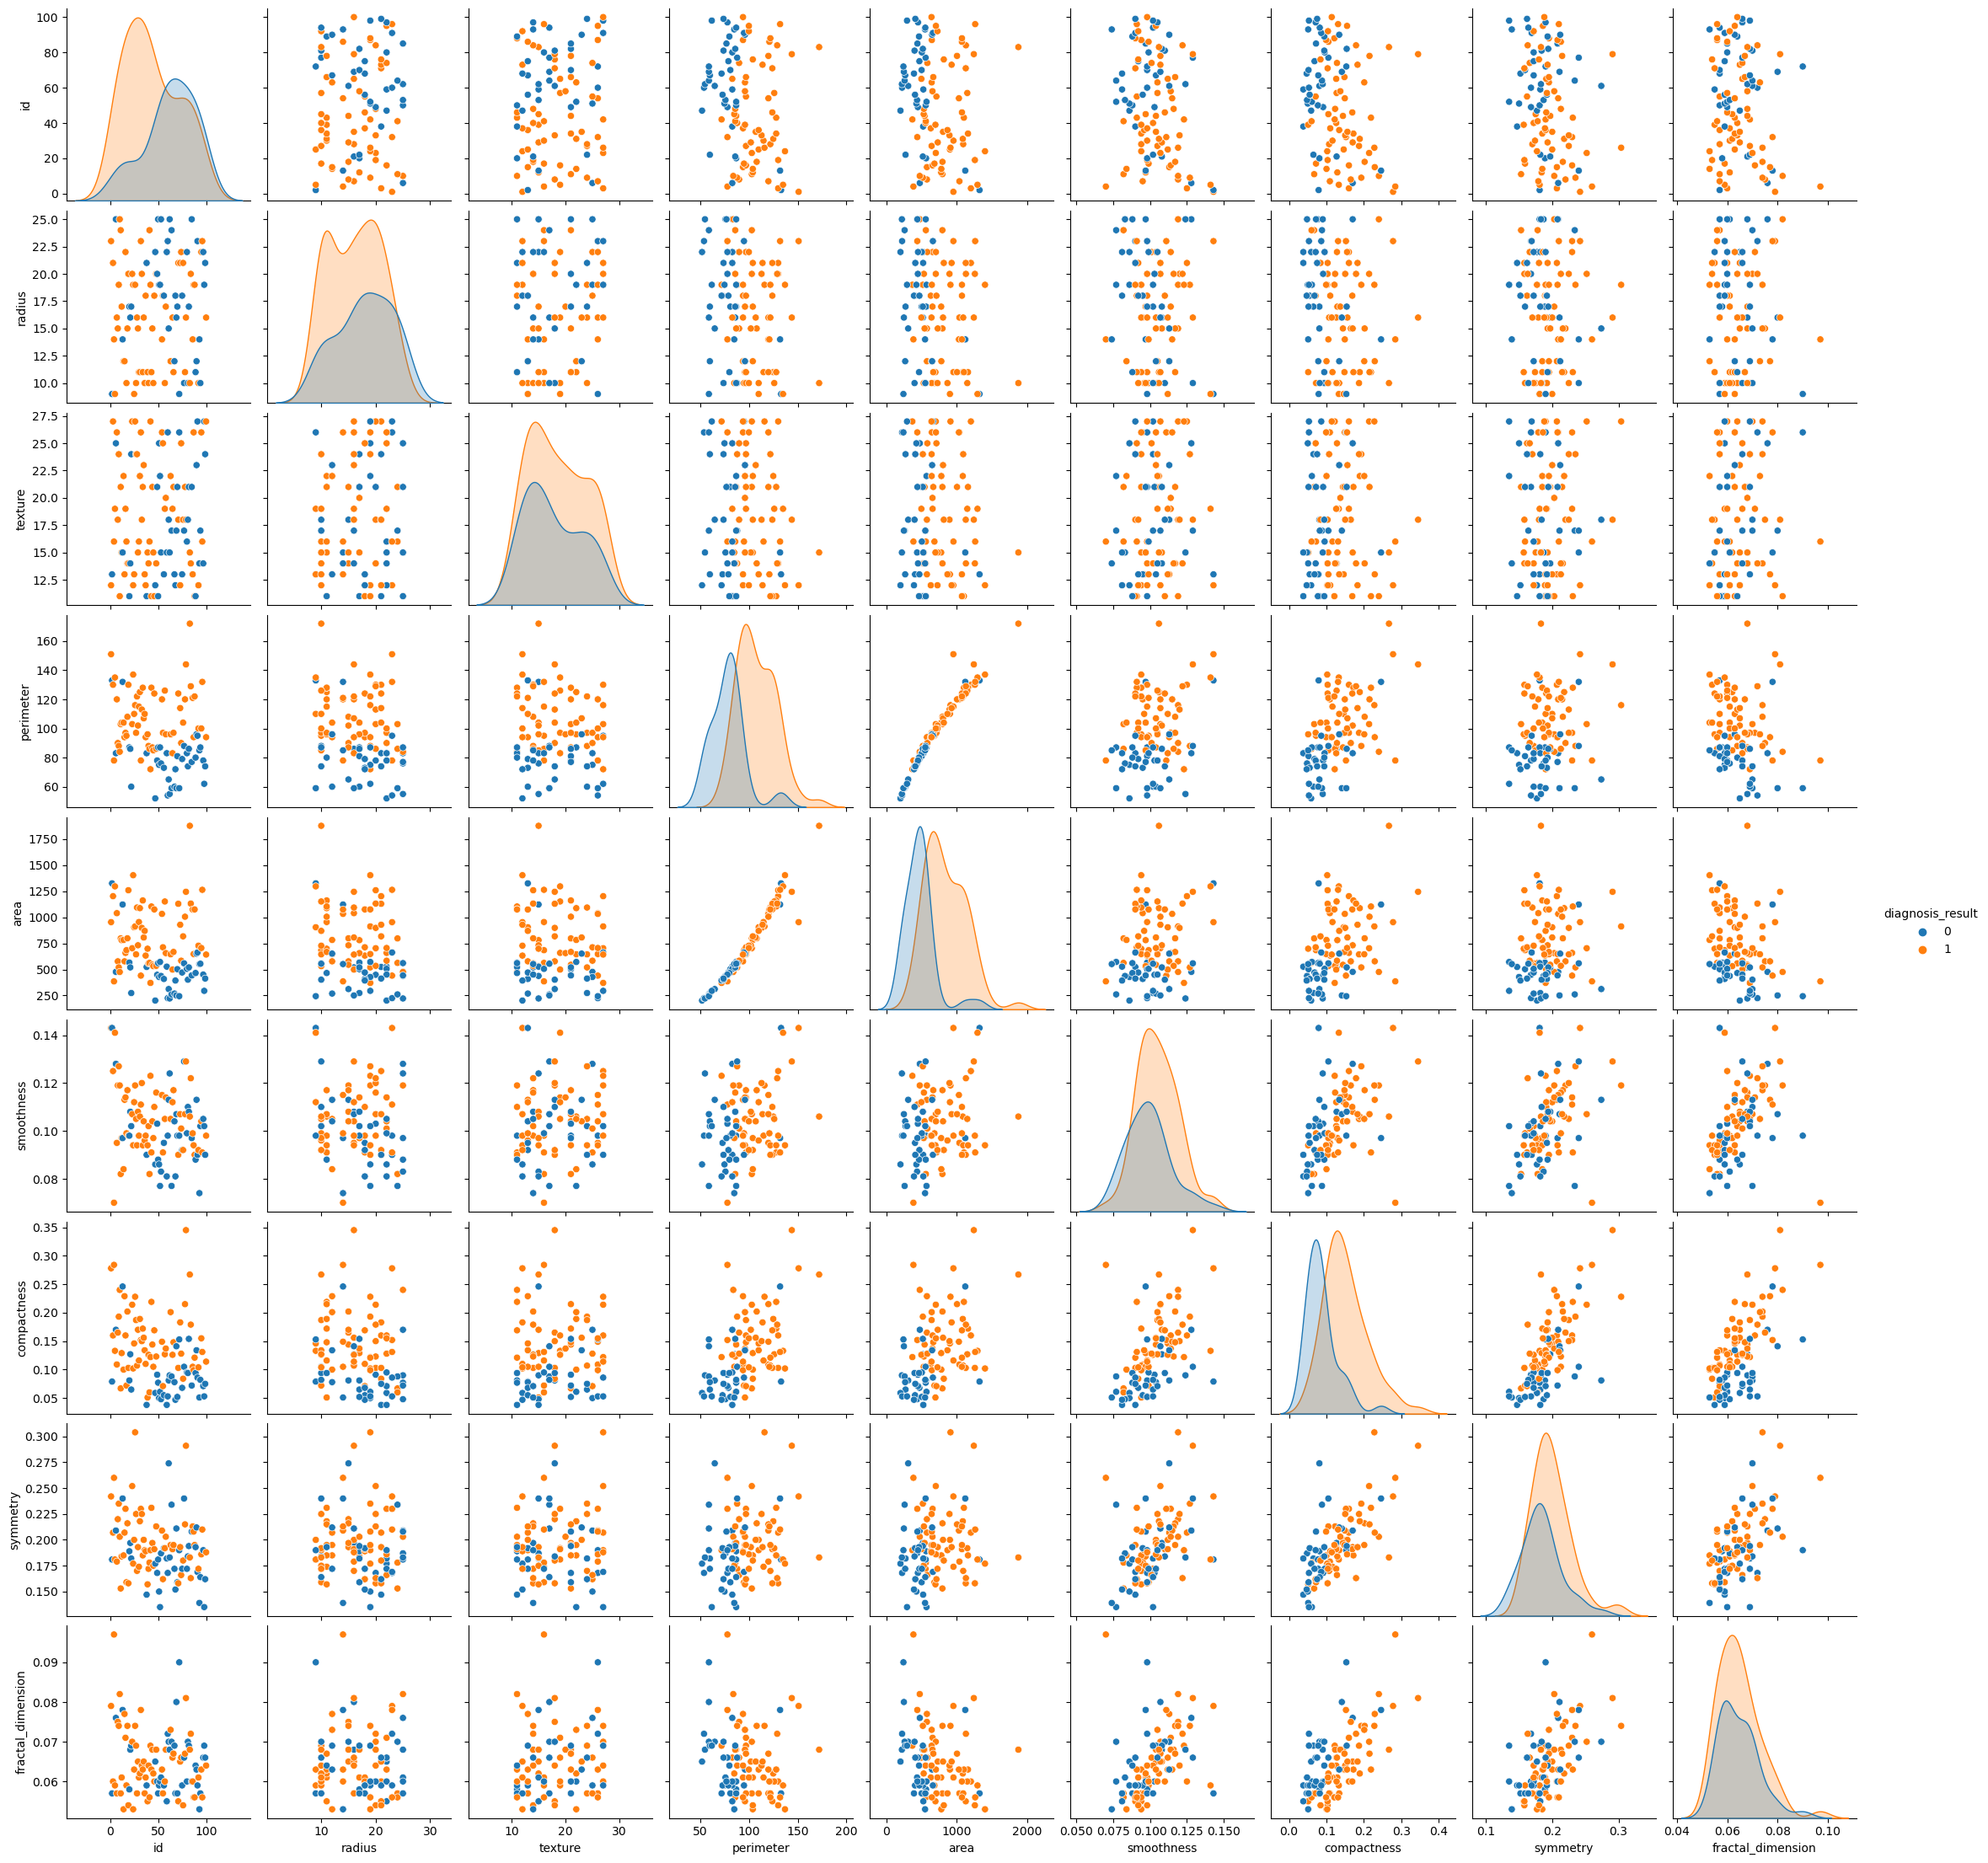

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer



# Create a copy of the data for EDA
eda_data = data.copy()
eda_data['diagnosis_result'] = eda_data['diagnosis_result'].map({'M': 1, 'B': 0})

# Pairplot to show the distributions and relations
sns.pairplot(eda_data, hue='diagnosis_result')


Feature-Target Split

In [12]:
# Features and target variable
X = data.drop(columns=['diagnosis_result', 'id']).copy()
y = data['diagnosis_result'].map({'M': 1, 'B': 0}).copy()

Data Preprocessing

In [13]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the features without changing the original X
X_scaled = scaler.fit_transform(X)

Data Splitting

In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Model Training and Evaluation

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score# Initialize the Logistic Regression model
logreg = LogisticRegression()

# Train the model
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.85


# Looking beyond the accuracy

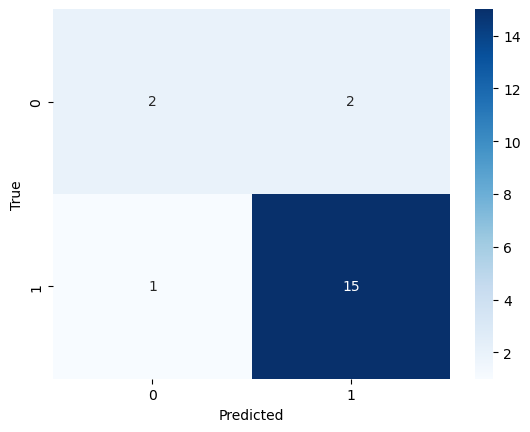

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Precision, Recall, and F1 Score

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.88      0.94      0.91        16

    accuracy                           0.85        20
   macro avg       0.77      0.72      0.74        20
weighted avg       0.84      0.85      0.84        20



In [18]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(logreg, X_scaled, y, cv=5)

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)


Cross-validation scores: [0.8  0.9  0.7  0.9  0.85]


# Predict Prostate Cancer

In [19]:
import numpy as np

def predict_prostate_cancer(logreg, scaler):
    # Collect user input for each question
    answers = []
    questions = [
        "Are you above 50 years old?",
        "Have you had elevated PSA levels?",
        "Do you have a family history of prostate cancer?",
        "Do you experience frequent urination or difficulty urinating?",
        "Do you have pain or discomfort in the pelvic area?",
        "Have you experienced unexplained weight loss recently?",
        "Have you noticed blood in your urine?",
        "Do you have difficulty maintaining an erection?"
    ]
    
    for question in questions:
        answer = input(question + " (yes/no): ")
        answers.append(1 if answer.lower() in ["yes", "y"] else -1)
    
    # Convert user inputs into a NumPy array suitable for the model
    input_features = np.array(answers).reshape(1, -1)
    
    # Preprocess the input features using the scaler
    input_features_scaled = scaler.transform(input_features)
    
    # Make the prediction and calculate the probability
    probability = logreg.predict_proba(input_features_scaled)[0, 1]

    # Calculate the total risk score
    risk_score = sum(answers) * 12.5
    risk_score = max(0, min(risk_score, 100))  # Ensuring the risk score is between 0% and 100%
    
    # Output the prediction along with the risk score
    print(f"Based on the answers provided, the calculated risk score is {risk_score:.2f}%.")
    print(f"The model's estimated probability of prostate cancer is {probability * 100:.2f}%.")

# Assuming your scaler and logistic regression model are named `scaler` and `logreg` respectively
predict_prostate_cancer(logreg, scaler)

Are you above 50 years old? (yes/no): yes
Have you had elevated PSA levels? (yes/no): yes
Do you have a family history of prostate cancer? (yes/no): no
Do you experience frequent urination or difficulty urinating? (yes/no): no
Do you have pain or discomfort in the pelvic area? (yes/no): yes
Have you experienced unexplained weight loss recently? (yes/no): no
Have you noticed blood in your urine? (yes/no): yes
Do you have difficulty maintaining an erection? (yes/no): yes
Based on the answers provided, the calculated risk score is 25.00%.
The model's estimated probability of prostate cancer is 0.00%.


C:\Users\Jlee\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
